# CGRP-Gamma clusters

Used log1p counts

SUbset: pretty neuron fraction
Clustering resolution from previou sscript is 0.25 so pretty coarse.

In [1]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

Timestamp: 2025-12-22 14:51:15.446687


In [2]:
from pathlib import Path
import sys
import os
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.patches as mpatches
import matplotlib.colors as clr
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import math
from matplotlib.colors import Normalize
import matplotlib.cm as cm
import seaborn as sns

In [3]:
plt.rcParams['figure.figsize'] = (3,3)
plt.rcParams["figure.dpi"] = 150

In [4]:
sys.path.append(str(Path.cwd().resolve().parents[1]))

from config.paths import BASE_DIR

input_dir = BASE_DIR / "data/h5ad/export_04/04b_reclustered"
output_dir = BASE_DIR / "2025-12-22"

output_dir.mkdir(parents=True, exist_ok=True)

input_file = input_dir / "neurons-seurat.h5ad"

In [5]:
sc.settings.figdir = output_dir

## Prepare data

In [6]:
adata = sc.read_h5ad(input_file)
adata.obs.EGFP_dTomato_dual_hi.value_counts()

EGFP_dTomato_dual_hi
False    22392
True        19
Name: count, dtype: int64

In [7]:
adata.X = adata.layers['log1p'].copy()

In [8]:
# subset to CGRP-Gamma
#adata = adata[adata.obs['seurat_labels'] == 'CGRP-Gamma'].copy()

### Create `reporter_status` column

In [9]:
# Define conditions with explicit exclusion to ensure dual-positives are prioritized
conditions = [
    adata.obs['EGFP_dTomato_dual_hi'] == True,
    (adata.obs['EGFP_Seq1_hi'] == True) & (adata.obs['EGFP_dTomato_dual_hi'] == False),
    (adata.obs['dTomato_Seq2_hi'] == True) & (adata.obs['EGFP_dTomato_dual_hi'] == False)
]

# Choices remain the same
choices = [
    'EGFP_dTomato_dual_hi', 
    'EGFP_Seq1_hi', 
    'dTomato_Seq2_hi'
]

adata.obs['reporter_status'] = np.select(conditions, choices, default='Negative')

# Convert to categorical for better plotting performance
adata.obs['reporter_status'] = adata.obs['reporter_status'].astype('category')

adata.obs.reporter_status.value_counts()

reporter_status
Negative                22264
dTomato_Seq2_hi            89
EGFP_Seq1_hi               39
EGFP_dTomato_dual_hi       19
Name: count, dtype: int64

### Create `innervation_pattern` column

In [10]:
# Define mapping for broader categories
innervation_map = {
    'EGFP_dTomato_dual_hi': 'Double-positive',
    'EGFP_Seq1_hi': 'Single-positive',
    'dTomato_Seq2_hi': 'Single-positive',
    'Negative': 'Negative'
}

# Apply the map to the existing reporter_status column
adata.obs['innervation_pattern'] = adata.obs['reporter_status'].map(innervation_map)

# Convert to categorical and set a logical order for plotting
adata.obs['innervation_pattern'] = adata.obs['innervation_pattern'].astype('category')
pattern_order = ['Double-positive', 'Single-positive', 'Negative']
adata.obs['innervation_pattern'] = adata.obs['innervation_pattern'].cat.reorder_categories(pattern_order)

print(adata.obs.innervation_pattern.value_counts())

innervation_pattern
Negative           22264
Single-positive      128
Double-positive       19
Name: count, dtype: int64


# CGRP-Gamma subset

In [11]:
print(adata.shape)
#adata = adata[adata.obs['seurat_labels'] == 'CGRP-Gamma'].copy()
print(adata.shape)

(22411, 475)
(22411, 475)


## First evaluate pre-existing clustering distribution

In [33]:
# DONUT PLOT

## Next set thresholds to assign G1/G2

In [12]:
adata.obs.neuron_recluster_seurat

aaadagcf-1     1
aaaihgjh-1     6
aabcohae-1     6
aabdncpn-1    11
aacblkbe-1     1
              ..
ncikkhpf-1     2
ncikogkk-1     7
ncpkkekg-1     2
ndabchac-1     3
oamhopio-1     3
Name: neuron_recluster_seurat, Length: 22411, dtype: category
Categories (12, object): ['0', '1', '2', '3', ..., '8', '9', '10', '11']

In [20]:
# 1. Identify the two most numerous clusters within CGRP-Gamma
gamma_mask = adata.obs['seurat_labels'] == 'CGRP-Gamma'
top_clusters = (
    adata.obs[gamma_mask]['neuron_recluster_seurat']
    .value_counts()
    .head(2)
    .index.tolist()
)

# 2. Calculate mean expression of markers for these two clusters to decide G1 vs G2
# We'll compare Chrna3 expression to distinguish them
cluster_expr = {}
for clus in top_clusters:
    # Calculate mean Chrna3 expression for this cluster
    mean_val = adata[adata.obs['neuron_recluster_seurat'] == clus, 'Chrna3'].X.mean()
    cluster_expr[clus] = mean_val

# The cluster with higher Chrna3 is G1, the other is G2
g1_cluster = max(cluster_expr, key=cluster_expr.get)
g2_cluster = [c for c in top_clusters if c != g1_cluster][0]

gamma_cluster_map = {
    str(g1_cluster): 'CGRP-Gamma 1',
    str(g2_cluster): 'CGRP-Gamma 2'
}

# 3. Apply the mapping exactly as before
def assign_unbiased_gamma(row):
    if row['seurat_labels'] == 'CGRP-Gamma':
        return gamma_cluster_map.get(str(row['neuron_recluster_seurat']), 'Other')
    return row['seurat_labels']

adata.obs['neuron_labels'] = adata.obs.apply(assign_unbiased_gamma, axis=1).astype('category')

Which one is G1 vs G2?

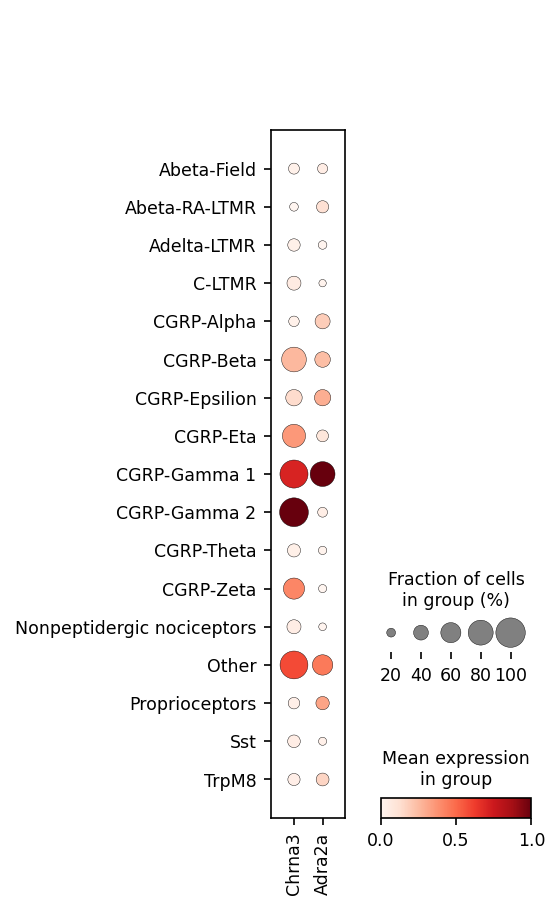

In [21]:
sc.pl.dotplot(adata, ['Chrna3', 'Adra2a'], groupby='seurat_labels_granular', standard_scale='var')

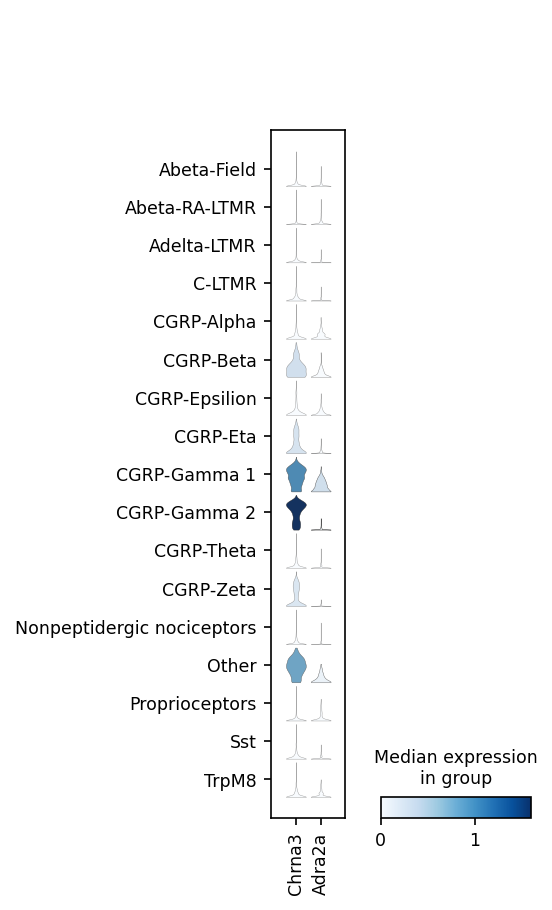

In [22]:
sc.pl.stacked_violin(
    adata, 
    var_names=['Chrna3', 'Adra2a'], 
    groupby='seurat_labels_granular', 
)

In [28]:
adata.obs.columns

Index(['cell_id', 'x_centroid', 'y_centroid', 'transcript_counts',
       'control_probe_counts', 'genomic_control_counts',
       'control_codeword_counts', 'unassigned_codeword_counts',
       'deprecated_codeword_counts', 'total_counts', 'cell_area',
       'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id',
       'output_id', 'region_id', 'slide_id', 'n_genes_by_counts',
       'log1p_n_genes_by_counts', 'log1p_total_counts',
       'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes',
       'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'batch',
       '_scvi_batch', '_scvi_labels', 'leiden_scVI_1', 'scanvi_labels',
       'seurat_labels', 'prediction.score.CGRP.Theta',
       'prediction.score.CGRP.Gamma', 'prediction.score.CGRP.Alpha',
       'prediction.score.Nonpeptidergic.nociceptors',
       'prediction.score.C.LTMR', 'prediction.score.Sst',
       'prediction.score.CGRP.Zeta', 'prediction.score.CGRP.Epsilion',
       'prediction.score.

In [25]:
adata.obs.seurat_labels_granular.value_counts()

seurat_labels_granular
CGRP-Gamma 1                  3811
Nonpeptidergic nociceptors    3513
CGRP-Gamma 2                  2087
CGRP-Eta                      1963
CGRP-Zeta                     1493
Abeta-RA-LTMR                 1463
Abeta-Field                   1452
C-LTMR                        1402
Adelta-LTMR                   1020
CGRP-Theta                     868
Proprioceptors                 864
TrpM8                          650
CGRP-Epsilion                  609
Sst                            554
Other                          288
CGRP-Alpha                     245
CGRP-Beta                      129
Name: count, dtype: int64

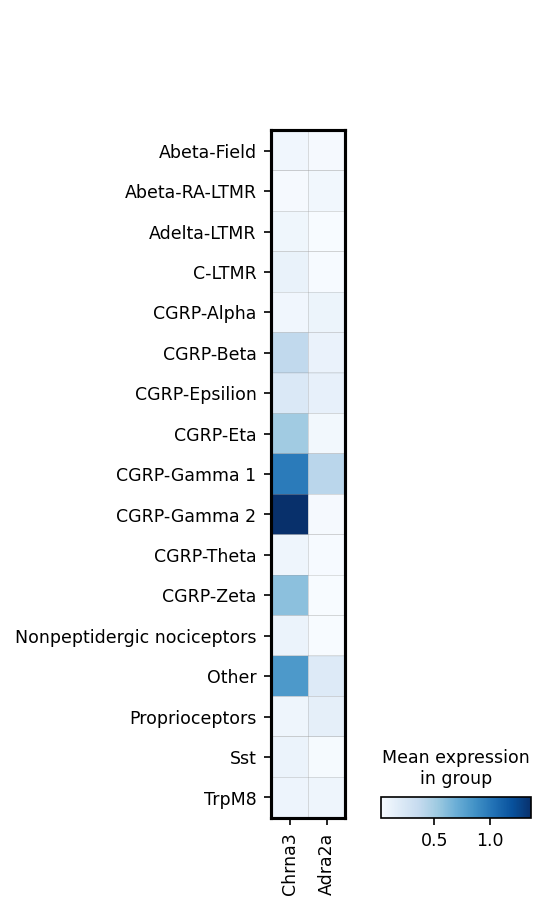

In [23]:
sc.pl.matrixplot(
    adata, 
    var_names=['Chrna3', 'Adra2a'], 
    groupby='seurat_labels_granular', 
    cmap = 'Blues'
)

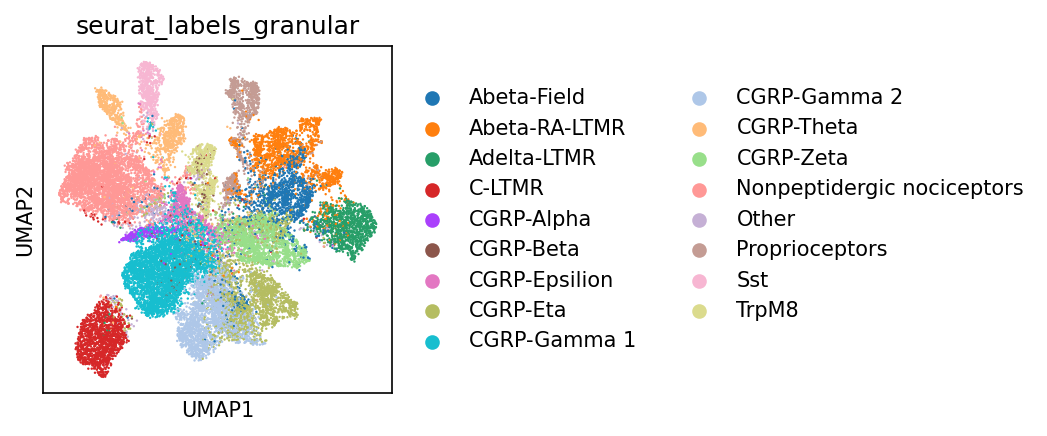

In [24]:
sc.pl.umap(adata, color = 'seurat_labels_granular')

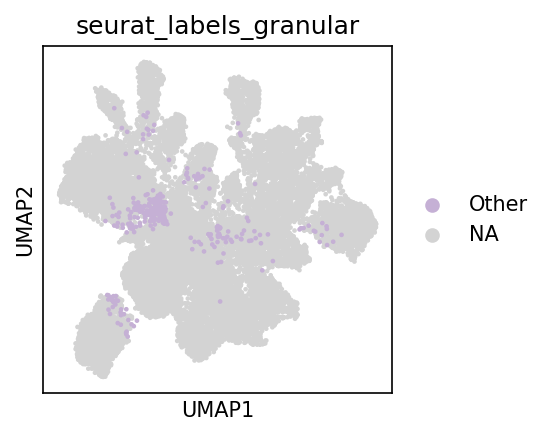

In [27]:
sc.pl.umap(
    adata, 
    color='seurat_labels_granular', 
    groups=['Other'], 
    # Remove the palette argument to avoid the KeyError
    na_color='lightgray', 
    size=20
)

In [31]:
adata.obs.reporter_status.value_counts()

reporter_status
Negative                22264
dTomato_Seq2_hi            89
EGFP_Seq1_hi               39
EGFP_dTomato_dual_hi       19
Name: count, dtype: int64

In [32]:
# Cross-tabulate your reporter status against the new taxonomy
dual_breakdown = pd.crosstab(
    adata.obs['reporter_status'], 
    adata.obs['seurat_labels_granular']
)

# Focus specifically on the dual hi row
print(dual_breakdown.loc[['EGFP_dTomato_dual_hi']])

seurat_labels_granular  Abeta-Field  Abeta-RA-LTMR  Adelta-LTMR  C-LTMR  \
reporter_status                                                           
EGFP_dTomato_dual_hi              0              0            0       0   

seurat_labels_granular  CGRP-Alpha  CGRP-Beta  CGRP-Epsilion  CGRP-Eta  \
reporter_status                                                          
EGFP_dTomato_dual_hi             0          0              0         1   

seurat_labels_granular  CGRP-Gamma 1  CGRP-Gamma 2  CGRP-Theta  CGRP-Zeta  \
reporter_status                                                             
EGFP_dTomato_dual_hi               1            17           0          0   

seurat_labels_granular  Nonpeptidergic nociceptors  Other  Proprioceptors  \
reporter_status                                                             
EGFP_dTomato_dual_hi                             0      0               0   

seurat_labels_granular  Sst  TrpM8  
reporter_status                     
EGFP_dTomato_

# merge

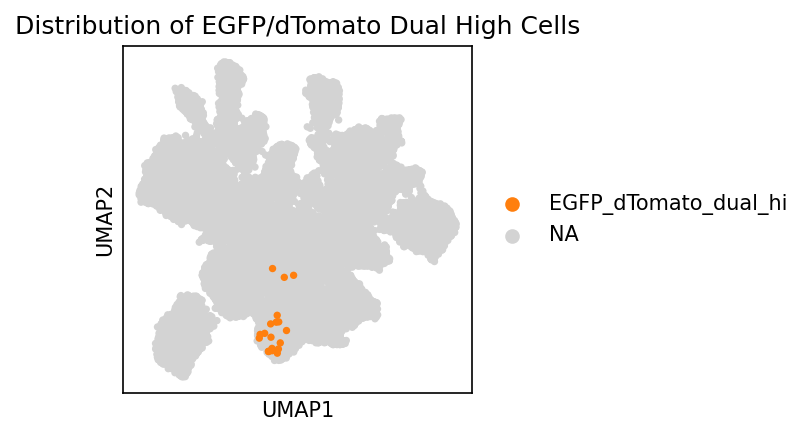

In [36]:
adta

In [19]:
import numpy as np

# Define the granular labels we want to prioritize
granular_targets = ['CGRP-Gamma (G1: Chrna3+)', 'CGRP-Gamma (G2: Adra2a+)']

# Define conditions: if the granular column has one of our target sub-types, use it
conditions = [
    adata.obs['seurat_labels_granular'].isin(granular_targets)
]

# Otherwise, fall back to the original seurat_labels
choices = [
    adata.obs['seurat_labels_granular'].astype(str)
]

# Create the new master column
adata.obs['neuron_labels'] = np.select(
    conditions, 
    choices, 
    default=adata.obs['seurat_labels'].astype(str)
)

# Convert to categorical for optimized plotting
adata.obs['neuron_labels'] = adata.obs['neuron_labels'].astype('category')

# Verify the merge
print(adata.obs['neuron_labels'].value_counts())

neuron_labels
CGRP-Gamma                    6186
Nonpeptidergic nociceptors    3513
CGRP-Eta                      1963
CGRP-Zeta                     1493
Abeta-RA-LTMR                 1463
Abeta-Field                   1452
C-LTMR                        1402
Adelta-LTMR                   1020
CGRP-Theta                     868
Proprioceptors                 864
TrpM8                          650
CGRP-Epsilion                  609
Sst                            554
CGRP-Alpha                     245
CGRP-Beta                      129
Name: count, dtype: int64
